Part 1:The attached data (APCuv.csv) are real data from a food industry experiment that is seeking to use a UV instrument to predict log10 APC levels in raw meat foodsamples. The UV instrument is a new method of ultraviolet bacteria detection; log10 APC refers to a log 10 transformation of aerobic plate count (a type ofbacteria). Raw meat product must be sampled to make sure bacteria levels arebelow what would indicate spoilage or potential safety concerns. Traditionalbacteria testing techniques is destructive to the product and requires a plating and incubation period of approximately 48 hours (a long time when trying to ship food products). The UV instrument attempts to instantly estimate the amount ofbacteria on the raw meat. However, a relationship between the UV reading and the tried and trusted log10 APC results must be established via a regression model. Building a good model would potentially speed up and improve the process of determining if there are any food safety issues in raw food. Using R (similar to the examples), build a regression model for the attached data to predict Log10APC results from UV light readings. Using 5-fold cross-validation, build a regression model, give the RMSE, Rsquare, and MAE, check that the F-test issignificant, build 95% prediction intervals and plot the model, and make aprediction for a new UV value. In a word document include the following: the regression model equation, whetherthe model is significant or not, the RMSE, Rsquare, and MAE for the out of sampledata, a graph of the model, write a sentence using the MAE that quantifies the uncertainty in the model, make a prediction for a new UV value (that is NOT extrapolation) that includes prediction intervals, and includes your full R program (R commands)

In [31]:
apc <- read.csv("C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/BDA Spring 26/Datasets/APCuv.csv")
head(apc)
colnames(apc) # 'UV''Log10APC'

,UV,Log10APC
,<dbl>,<dbl>
1,0.1881,3.089905
2,0.2613,5.280009
3,0.2572,4.019947
4,0.1493,2.799341
5,0.0805,2.778151
6,0.1985,2.431364


[1] "UV"       "Log10APC"

In [32]:
library(caret)
 
#we set a seed so that the random sampling will be repeatable
set.seed(42)
 
# Set up 5-fold cross-validation
train_control <- trainControl(method = "cv",number = 5)
 
# fit the model
model <- train(Log10APC ~UV, data = apc,
               method = "lm",
               trControl = train_control)

# Evaluating the model
print(model)

# Linear Regression 

# 99 samples
#  1 predictor

# No pre-processing
# Resampling: Cross-Validated (5 fold) 
# Summary of sample sizes: 80, 79, 79, 79, 79 
# Resampling results:

#   RMSE       Rsquared   MAE      
#   0.6549595  0.5576996  0.5402461

# Tuning parameter 'intercept' was held constant at a value of TRUE
summary(model)

# Call:
# lm(formula = .outcome ~ ., data = dat)

# Residuals:
#      Min       1Q   Median       3Q      Max 
# -1.27583 -0.45255  0.01043  0.43262  1.68059 

# Coefficients:
#             Estimate Std. Error t value Pr(>|t|)    
# (Intercept)   1.5238     0.1625   9.377 2.97e-15 ***
# UV           10.0918     0.9360  10.782  < 2e-16 ***
# ---
# Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

# Residual standard error: 0.6611 on 97 degrees of freedom
# Multiple R-squared:  0.5451,	Adjusted R-squared:  0.5404 
# F-statistic: 116.2 on 1 and 97 DF,  p-value: < 2.2e-16
print("regression model is significant")

Linear Regression 

99 samples
 1 predictor

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 80, 79, 79, 79, 79 
Resampling results:

  RMSE       Rsquared   MAE      
  0.6549595  0.5576996  0.5402461

Tuning parameter 'intercept' was held constant at a value of TRUE



Call:
lm(formula = .outcome ~ ., data = dat)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.27583 -0.45255  0.01043  0.43262  1.68059 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   1.5238     0.1625   9.377 2.97e-15 ***
UV           10.0918     0.9360  10.782  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.6611 on 97 degrees of freedom
Multiple R-squared:  0.5451,	Adjusted R-squared:  0.5404 
F-statistic: 116.2 on 1 and 97 DF,  p-value: < 2.2e-16


[1] "regression model is significant"


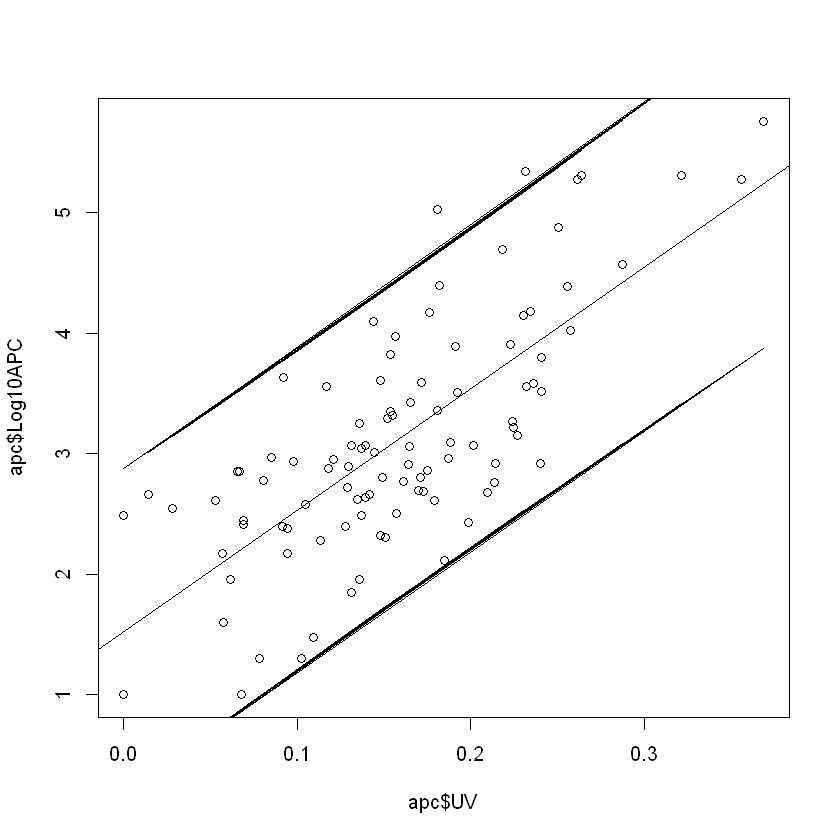

In [33]:
regmodel<-lm(Log10APC~UV,data=apc)
plot(apc$UV,apc$Log10APC)
abline(regmodel)
pred_interval <- predict(regmodel, newdata=apc, interval="prediction",level = 0.95)
lines(apc$UV, pred_interval[,2])
lines(apc$UV, pred_interval[,3])

In [35]:
# make a prediction
newdata=data.frame(
    UV = 0.5 # make the prediction within the range 
                   )
predict(regmodel,newdata=newdata,interval="prediction",level=0.95) 

# 	fit	lwr	upr
# 1	6.569686	5.106341	8.03303

,fit,lwr,upr
1,6.569686,5.106341,8.03303


Part 2:The attached data (halloweenCandy.csv) are retail sales data for stores in a largeretail chain in the weeks nearing Halloween. Some stores ran out of Halloweencandy in a previous year, using the attached data from stores that did not run outof candy, we want to build a model to predict Halloween candy sales based on thesales of other items (so that predictions can be made on how much candy shouldbe ordered for this year for stores that ran out last year). The file halloweenCandy,contains sales data in columns for Candy (Halloween Candy sales), Costume(Halloween costume sales), Decorations (Halloween decoration sales), and Pumpkin(sales of pumpkin). You do NOT need to do exploratory data analysis on thesedata (in real life you would). Build a model to predict Candy Sales (assumeCostume, Decorations, and Pumpkin Sales are all needed--you do NOT have to dovariable selection), use 5-fold cross-validation, give the RMSE, Rsquare, and MAE,check that the F-test is significant, and to demonstrate the model make a newprediction of Candy Sales for new values of costume, decorations, pumkinsales. Add to part 1 in your word document by including the following: theregression model equation, whether the model is significant or not, the RMSE,Rsquare, and MAE for the out of sample data, write a sentence using the MAE thatquantifies the uncertainty in the model, make a prediction for a new inputs (that isNOT extrapolation) that includes prediction intervals, and includes your full Rprogram (R commands).

In [27]:
df <- read.csv("C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/BDA Spring 26/Datasets/halloweenCandy.csv")
head(df)
colnames(df) # 'Candy''Costume''Decorations''Pumpkin'

,Candy,Costume,Decorations,Pumpkin
,<dbl>,<dbl>,<dbl>,<dbl>
1,3208.63,4318.51,2739.35,1974.23
2,4994.08,6203.88,3325.69,3834.30
3,5102.14,4604.13,2773.87,2818.22
4,2979.45,4476.37,2972.68,1771.11
5,4830.74,4224.13,2585.14,3201.03
6,4974.81,4728.35,3322.54,3307.52


[1] "Candy"       "Costume"     "Decorations" "Pumpkin"

In [28]:
library(caret)
 
#we set a seed so that the random sampling will be repeatable
set.seed(42)
 
# Set up 5-fold cross-validation
train_control <- trainControl(method = "cv",number = 5)
 
# fit the model
model <- train(Candy ~., data = df, method = "lm", trControl =
train_control)

# Evaluating the model
print(model)

# Linear Regression 

# 218 samples
#   3 predictor

# No pre-processing
# Resampling: Cross-Validated (5 fold) 
# Summary of sample sizes: 174, 174, 174, 175, 175 
# Resampling results:

#   RMSE      Rsquared   MAE     
#   623.4669  0.3054206  517.2052

# Tuning parameter 'intercept' was held constant at a value of TRUE

summary(model)

# Call:
# lm(formula = .outcome ~ ., data = dat)

# Residuals:
#      Min       1Q   Median       3Q      Max 
# -1540.52  -438.26   -37.37   502.13  1622.91 

# Coefficients:
#              Estimate Std. Error t value Pr(>|t|)    
# (Intercept) 363.04612  420.31956   0.864 0.388699    
# Costume       0.35141    0.05026   6.992 3.41e-11 ***
# Decorations   0.36881    0.10485   3.517 0.000532 ***
# Pumpkin       0.36794    0.06403   5.747 3.10e-08 ***
# ---
# Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

# Residual standard error: 624 on 214 degrees of freedom
# Multiple R-squared:  0.3071,	Adjusted R-squared:  0.2973 
# F-statistic: 31.61 on 3 and 214 DF,  p-value: < 2.2e-16
print("regression model is significant")

Linear Regression 

218 samples
  3 predictor

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 174, 174, 174, 175, 175 
Resampling results:

  RMSE      Rsquared   MAE     
  623.4669  0.3054206  517.2052

Tuning parameter 'intercept' was held constant at a value of TRUE



Call:
lm(formula = .outcome ~ ., data = dat)

Residuals:
     Min       1Q   Median       3Q      Max 
-1540.52  -438.26   -37.37   502.13  1622.91 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 363.04612  420.31956   0.864 0.388699    
Costume       0.35141    0.05026   6.992 3.41e-11 ***
Decorations   0.36881    0.10485   3.517 0.000532 ***
Pumpkin       0.36794    0.06403   5.747 3.10e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 624 on 214 degrees of freedom
Multiple R-squared:  0.3071,	Adjusted R-squared:  0.2973 
F-statistic: 31.61 on 3 and 214 DF,  p-value: < 2.2e-16


In [36]:
regmodel<-lm(Candy~.,data=df)
summary(df) #to see max and min of inputs
# 'Candy''Costume''Decorations''Pumpkin'
newdata=data.frame(Candy = 3900, 
                   Costume = 4000,
                   Decorations = 3000,
                  Pumpkin = 3000)
predict(regmodel,newdata=newdata,interval="prediction",level=0.95)

#    Candy         Costume      Decorations      Pumpkin      
#  Min.   :2411   Min.   :2095   Min.   :1979   Min.   : 931.5  
#  1st Qu.:3495   1st Qu.:3474   1st Qu.:2721   1st Qu.:2674.1  
#  Median :3978   Median :4064   Median :2975   Median :3033.2  
#  Mean   :4023   Mean   :4076   Mean   :3001   Mean   :3046.9  
#  3rd Qu.:4567   3rd Qu.:4673   3rd Qu.:3320   3rd Qu.:3488.0  
#  Max.   :5840   Max.   :6204   Max.   :3863   Max.   :4883.5  
# A matrix: 1 × 3 of type dbl
# fit	lwr	upr
# 1	3978.96	2746.176	5211.745

     Candy         Costume      Decorations      Pumpkin      
 Min.   :2411   Min.   :2095   Min.   :1979   Min.   : 931.5  
 1st Qu.:3495   1st Qu.:3474   1st Qu.:2721   1st Qu.:2674.1  
 Median :3978   Median :4064   Median :2975   Median :3033.2  
 Mean   :4023   Mean   :4076   Mean   :3001   Mean   :3046.9  
 3rd Qu.:4567   3rd Qu.:4673   3rd Qu.:3320   3rd Qu.:3488.0  
 Max.   :5840   Max.   :6204   Max.   :3863   Max.   :4883.5  

,fit,lwr,upr
1,3978.96,2746.176,5211.745
